# Adaptive Electronic Warfare System using DSP

## Objective:
## 1.)To detect signals in noisy environments and apply adaptive jamming.

## 2.) Methodology

### i)Signal generation

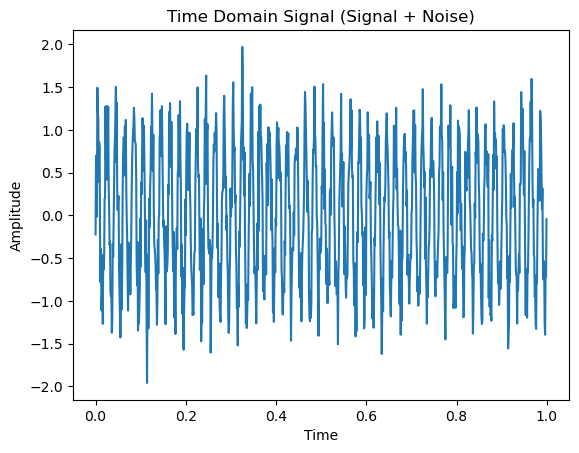

In [22]:
# STEP 1: Signal Generation
import numpy as np
import matplotlib.pyplot as plt

fs = 1000  # Sampling frequency
t = np.arange(0, 1, 1/fs)

# Create a sine wave (signal)
freq_signal = 50  # Hz
signal = np.sin(2 * np.pi * freq_signal * t)

# Create noise
noise = np.random.normal(0, 0.3, len(t))

# Combine both
combined = signal + noise

# Plot
plt.plot(t, combined)
plt.title("Time Domain Signal (Signal + Noise)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### ii)FFT analysis

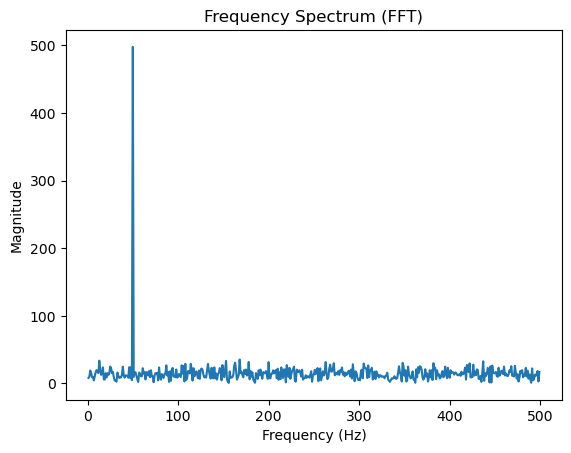

In [4]:
# STEP 2: FFT Analysis

fft_vals = np.fft.fft(combined)
freqs = np.fft.fftfreq(len(fft_vals), 1/fs)

# Only positive frequencies
mask = freqs > 0
freqs = freqs[mask]
fft_vals = np.abs(fft_vals[mask])

# Plot FFT
plt.plot(freqs, fft_vals)
plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

### iii)Signal detection

In [ ]:
# STEP 3: Signal Detection

threshold = np.mean(fft_vals) * 5  # adjust if needed

peak_value = np.max(fft_vals)
dominant_freq = freqs[np.argmax(fft_vals)]

if peak_value > threshold:
    print(f"Signal Detected at {dominant_freq:.2f} Hz")
else:
    print("No significant signal detected")

plt.axvline(dominant_freq, color='r', linestyle='--', label='Detected Signal')
plt.legend()

### iv) Jamming

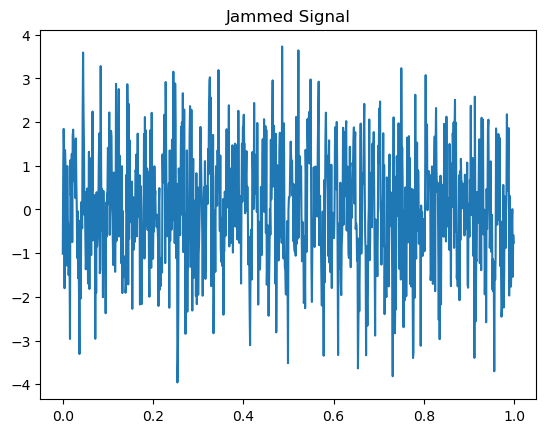

In [6]:
# STEP 4: Noise Jamming

jammer = np.random.normal(0, 1, len(t))
jammed_signal = combined + jammer

# Plot
plt.plot(t, jammed_signal)
plt.title("Jammed Signal")
plt.show()

### v)Filtering

In [8]:
# STEP 5: Adaptive Band-Stop Filter

from scipy.signal import butter, lfilter

def bandstop_filter(data, lowcut, highcut, fs):
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='bandstop')
    return lfilter(b, a, data)

# Apply around detected frequency
lowcut = dominant_freq - 5
highcut = dominant_freq + 5

filtered_signal = bandstop_filter(combined, lowcut, highcut, fs)

## 3.) Results

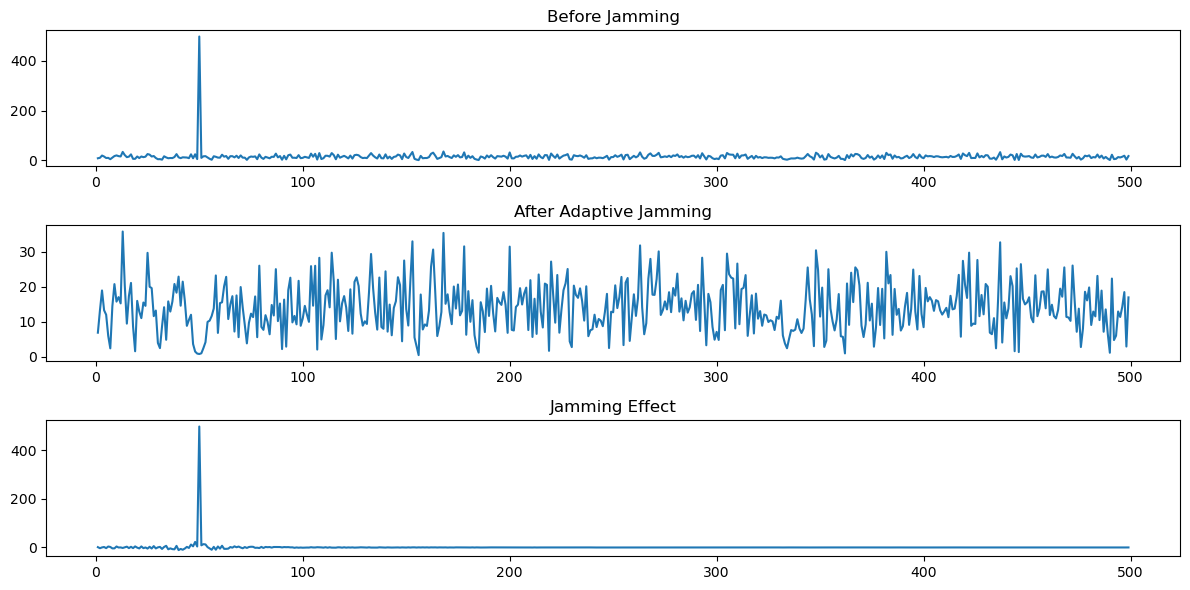

In [14]:
plt.figure(figsize=(12,6))

plt.subplot(3,1,1)
plt.plot(freqs, fft_vals)
plt.title("Before Jamming")

plt.subplot(3,1,2)
plt.plot(freqs, fft_jammed)
plt.title("After Adaptive Jamming")

plt.subplot(3,1,3)
plt.plot(freqs, fft_vals - fft_jammed)
plt.title("Jamming Effect")

plt.tight_layout()
plt.show()

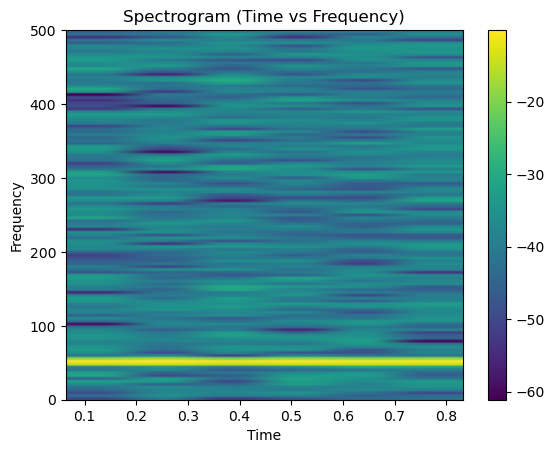

In [15]:
# STEP 7: Spectrogram

plt.specgram(combined, Fs=fs)
plt.title("Spectrogram (Time vs Frequency)")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.show()

## 4.) Conclusion

#### System successfully detects and jams signals.